In [1]:
# 9 Marks Practice Question
# Use 'loan_approval_dataset.csv' to create a dataset.
# Remove 'loan_id' from dataset
# check for null and duplicates in dataset, drop them if present.
# Remove Outliers from 'bank_asset_value' column.
# Create new column named 'total_asset_value' as a sum of residential_assets_value, commercial_assets_value, luxury_assets_value bank_asset_value
# Remove residential_assets_value, commercial_assets_value, luxury_assets_value bank_asset_value columns.
# Remove rows from dataset if 'loan_status' column have 'Not Known' in it.
# target column - 'loan_status'
# features - All columns except 'loan_status'
# Create kNN(neighbors=21),Decision Tree(criterion=entropy, random_state=42),SVM(C=20),RandomForest(criterion=entropy, random_state=42) for testing size(0.1,0.2,0.3,0.4)
# Create a line plot comparing accuracy of all models for each testing size.

In [33]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.DataFrame(pd.read_csv("loan_approval_dataset.csv"));
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,NotGraduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,NotGraduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,NotGraduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,NotGraduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,NotGraduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [4]:
df = df.drop("loan_id",axis=1)
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,NotGraduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,NotGraduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,NotGraduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,NotGraduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,NotGraduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [5]:
print(df.isna().sum())

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
print(df.shape)

(4269, 12)


In [8]:
q3 = df["bank_asset_value"].quantile(0.75)
q1 = df["bank_asset_value"].quantile(0.25)
iqr = q3-q1
upper = q3+(iqr*1.5)
lower = q1-(iqr*1.5)
df = df[(df["bank_asset_value"]<=upper)&(df["bank_asset_value"]>=lower)]
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,NotGraduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,NotGraduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,NotGraduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,NotGraduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,NotGraduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [9]:
df["total_asset_value"]=df["residential_assets_value"]+df["commercial_assets_value"]+df["luxury_assets_value"]+df["bank_asset_value"]

C:\Users\LJENG\AppData\Local\Temp\ipykernel_8980\1181138854.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["total_asset_value"]=df["residential_assets_value"]+df["commercial_assets_value"]+df["luxury_assets_value"]+df["bank_asset_value"]


In [10]:
df = df.drop(["residential_assets_value","commercial_assets_value","luxury_assets_value","bank_asset_value"],axis=1)
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,loan_status,total_asset_value
0,2,Graduate,No,9600000,29900000,12,778,Approved,50700000
1,0,NotGraduate,Yes,4100000,12200000,8,417,Rejected,17000000
2,3,Graduate,No,9100000,29700000,20,506,Rejected,57700000
3,3,Graduate,No,8200000,30700000,8,467,Rejected,52700000
4,5,NotGraduate,Yes,9800000,24200000,20,382,Rejected,55000000
...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,Rejected,7400000
4265,0,NotGraduate,Yes,3300000,11300000,20,559,Approved,20000000
4266,2,NotGraduate,No,6500000,23900000,18,457,Rejected,39000000
4267,1,NotGraduate,No,4100000,12800000,8,780,Approved,28800000


In [11]:
df=df[df["loan_status"]!="Not Known"]
df.shape

(4261, 9)

In [19]:
x=df.drop("loan_status",axis=1)
y=df["loan_status"]
x=pd.get_dummies(x)


[0.585480093676815, 0.6060961313012896, 0.6059421422986708, 0.6005865102639296]

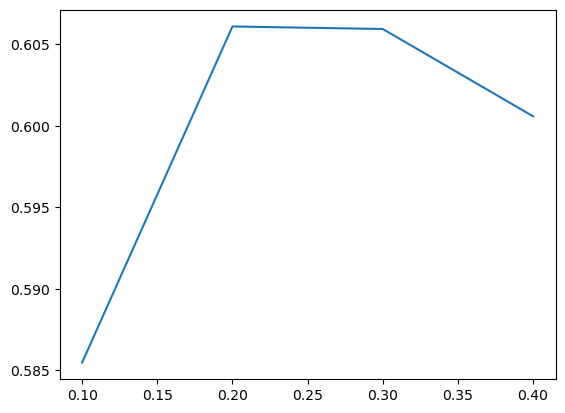

In [27]:
test = [0.1,0.2,0.3,0.4]
accuracy1 = []
for i in test:
    x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=i,random_state=42)
    model = KNeighborsClassifier(n_neighbors=21)
    model.fit(x_train,y_train)
    pre = model.predict(x_test)
    acc = accuracy_score(y_test,pre)
    accuracy1.append(acc)
sns.lineplot(x=test,y=accuracy1)
accuracy1

[0.9789227166276346,
 0.9824150058616647,
 0.9679437060203284,
 0.9759530791788856]

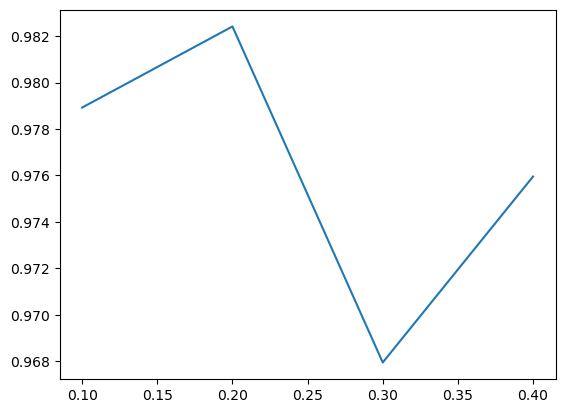

In [28]:
test = [0.1,0.2,0.3,0.4]
accuracy2 = []
for i in test:
    x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=i,random_state=42)
    model = DecisionTreeClassifier(criterion="entropy",random_state=42)
    model.fit(x_train,y_train)
    pre = model.predict(x_test)
    acc = accuracy_score(y_test,pre)
    accuracy2.append(acc)
sns.lineplot(x=test,y=accuracy2)
accuracy2

[0.629976580796253, 0.6295427901524033, 0.619233776387803, 0.6099706744868035]

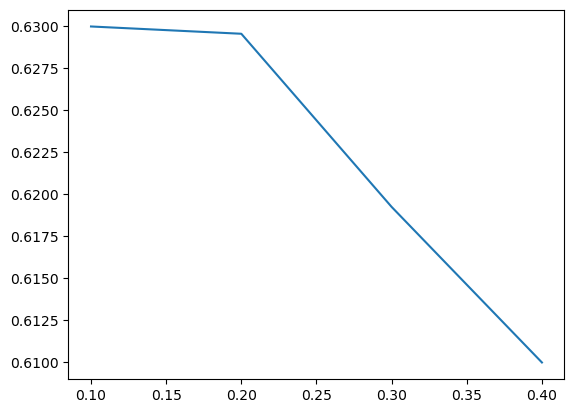

In [29]:
test = [0.1,0.2,0.3,0.4]
accuracy3 = []
for i in test:
    x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=i,random_state=42)
    model = SVC(C=20)
    model.fit(x_train,y_train)
    pre = model.predict(x_test)
    acc = accuracy_score(y_test,pre)
    accuracy3.append(acc)
sns.lineplot(x=test,y=accuracy3)
accuracy3

[0.9742388758782201,
 0.9835873388042204,
 0.9734167318217357,
 0.9747800586510263]

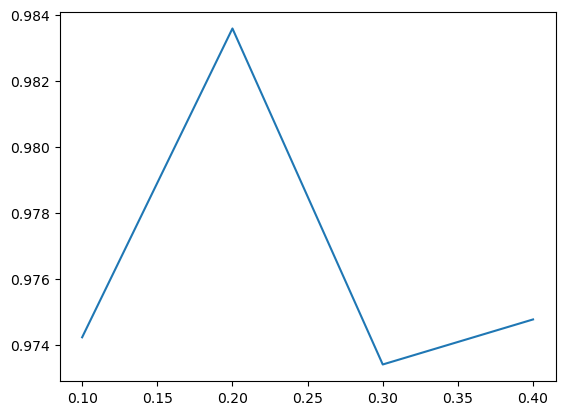

In [30]:
test = [0.1,0.2,0.3,0.4]
accuracy4 = []
for i in test:
    x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=i,random_state=42)
    model = RandomForestClassifier(criterion="entropy", random_state=42)
    model.fit(x_train,y_train)
    pre = model.predict(x_test)
    acc = accuracy_score(y_test,pre)
    accuracy4.append(acc)
sns.lineplot(x=test,y=accuracy4)
accuracy4

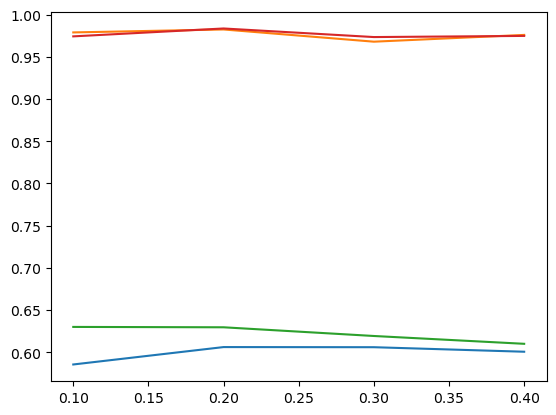

In [36]:
sns.lineplot(x=test,y=accuracy1)
sns.lineplot(x=test,y=accuracy2)
sns.lineplot(x=test,y=accuracy3)
sns.lineplot(x=test,y=accuracy4)
plt.show()